In [5]:
import torch

tensor = torch.tensor([1.0, 2.0, 3.0])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# We move our tensor to the GPU if available
if torch.cuda.is_available():
  tensor = tensor.to('cuda')
  print(f"Device tensor is stored on: {tensor.device}")

Device tensor is stored on: cuda:0


In [6]:
import torch
import torchvision
import torchvision.transforms as transforms

print("modules loaded")

modules loaded


In [7]:

# clean data for validating and testing
test_transform = transforms.Compose([
    transforms.Resize(280),
    transforms.CenterCrop((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# augmented data for training
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(256),
    transforms.TrivialAugmentWide(),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
weather_images = torchvision.datasets.ImageFolder(root='dataset')

# 3. Split the raw data
train_raw, test_raw, val_raw = torch.utils.data.random_split(weather_images, [0.6, 0.2, 0.2])

# 4. WRAP them in a class or apply transform manually
# In PyTorch, random_split returns a Subset. To give them different transforms:
class ApplyTransform(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform: x = self.transform(x)
        return x, y
    def __len__(self):
        return len(self.subset)

# Dotychczasowy błąd polegał na tym, że trainset i valset używały tych samych transformacji.
# Nie powinny, ponieważ augmentacje powinny być stosowane tylko do zbioru treningowego.
# dlaczego? Bo augmentacje mają na celu zwiększenie różnorodności danych treningowych, co pomaga modelowi
# uczyć się bardziej ogólnych cech i unikać przeuczenia. Zbiór walidacyjny i testowy powinny odzwierciedlać rzeczywiste dane,
# na których model będzie działał, więc nie powinny zawierać sztucznych zmian.
trainset = ApplyTransform(train_raw, transform=train_transform)
testset = ApplyTransform(test_raw, transform=test_transform)
valset = ApplyTransform(val_raw, transform=test_transform)

batch_size = 16

trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)


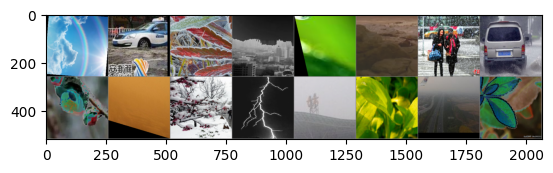

rainbow rain  frost fogsmog dew   sandstorm snow  rain  glaze sandstorm snow  lightning fogsmog dew   fogsmog frost


torch.Size([3, 256, 256])

In [8]:
# sposób wyświetlenia obrazków i labelek

import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{trainloader.dataset.subset.dataset.classes[labels[j]]:5s}' for j in range(batch_size)))

images[0].shape

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch

import torch
import torch.nn as nn
import torch.nn.functional as F


# AI Pomogło
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        # First Convolution
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        # Second Convolution
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection (Identity mapping)
        self.shortcut = nn.Sequential()
        
        # If input/output dimensions don't match, we must transform the identity
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = x
        
        # First convolution
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)

        # Second convolution
        out = self.conv2(out)
        out = self.bn2(out)
        
        # The core Residual logic: Element-wise addition
        out += self.shortcut(identity)
        out = F.relu(out)
        
        return out


class ResNet(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(ResNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 128, kernel_size=3, stride=1, padding=1, bias=False)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2, padding=0)

        self.bn1 = nn.BatchNorm2d(128)
        self.res_layer_1 = self._make_layer(128, 256, stride=2)
        self.res_layer_2 = self._make_layer(256, 512, stride=1)
        self.res_layer_3 = self._make_layer(512, 1024, stride=1)


        # To sprawia, że niezależnie od rozmiaru wejściowego obrazu, wyjście z warstw konwolucyjnych będzie miało rozmiar 1x1 przed wejściem do warstwy w pełni połączonej - pytorch sam dobierze parametry poolowania by to zapewnić
        # Utracone informacje dotyczą umieszczenia features w obrazie, ale dla klasyfikacji całych obrazów nie ma to większego znaczenia
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # mapowanie rezultatów na klasy
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, stride):
        layers = []
        layers.append(ResidualBlock(in_channels, out_channels, stride))
        layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution - prepare for residual layers
        out = self.conv1(x)
        out = self.pool(out)
        out = self.bn1(out)
        out = F.relu(out)
        # print(out.size())

        # # Residual layers
        out = self.res_layer_1(out)
        out = self.res_layer_2(out)
        # out = self.res_layer_3(out)
        # print(out.size())
        # # Output from residual layers to fully connected layer
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

net = ResNet(3, trainloader.dataset.subset.dataset.classes.__len__())
net.to(device)
print(net)

ResNet(
  (conv1): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res_layer_1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride

In [10]:
torch.cuda.empty_cache()

In [ ]:
# Updated tracking structures

# - Zero (the gradients)

# - Forward (get predictions)

# - Loss (calculate error)

# - Backward (calculate gradients)

# - Step (update weights)

print("START TRAINING")
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
EPOCHS = 400
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(net.parameters(), lr=0.01, betas=(0.9, 0.999), weight_decay=1e-4)

for epoch in range(EPOCHS):
    net.train()
    running_train_loss = 0.0
    
    for inputs, labels in trainloader:
        inputs, labels = inputs.to('cuda'), labels.to('cuda')
        
        optimizer.zero_grad()
        # net.forward(inputs)
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item()

    # Calculate average epoch loss
    epoch_train_loss = running_train_loss / len(trainloader)
    
    # Validation Phase
    net.eval()
    running_val_loss = 0.0
    correct = 0
    
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to('cuda'), labels.to('cuda')
            outputs = net(inputs)
            running_val_loss += criterion(outputs, labels).item()
            
            pred = outputs.argmax(dim=1)
            correct += (pred == labels).sum().item()

    epoch_val_loss = running_val_loss / len(valloader)
    epoch_val_acc = correct / len(valloader.dataset)

    # Store metrics once per epoch for clean plotting
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)
    
    torch.save(net.state_dict(), 'checkpoints/resnet_epoch_{}.pth'.format(epoch+1))

    # early stopping if Val Loss does not improve for 5 consecutive epochs
    if epoch > 5:
        if all(history['val_loss'][-1] >= history['val_loss'][-i] for i in range(2, 2 + 5)):
            print("Early stopping triggered")
            break

    print(f"Epoch {epoch+1} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

torch.save(net.state_dict(), 'weather_resnet.pth')

START TRAINING


Epoch 1 | Train Loss: 2.1225 | Val Loss: 1.6298
Epoch 2 | Train Loss: 1.7290 | Val Loss: 1.3928
Epoch 3 | Train Loss: 1.6665 | Val Loss: 1.3682
Epoch 4 | Train Loss: 1.6187 | Val Loss: 1.4688
Epoch 5 | Train Loss: 1.5973 | Val Loss: 1.3820
Epoch 6 | Train Loss: 1.5500 | Val Loss: 1.2522
Epoch 7 | Train Loss: 1.5341 | Val Loss: 1.2853
Epoch 8 | Train Loss: 1.5115 | Val Loss: 1.1902
Epoch 9 | Train Loss: 1.4683 | Val Loss: 1.1451
Epoch 10 | Train Loss: 1.4385 | Val Loss: 1.1263
Epoch 11 | Train Loss: 1.4021 | Val Loss: 1.1110
Epoch 12 | Train Loss: 1.3858 | Val Loss: 1.0781
Epoch 13 | Train Loss: 1.3714 | Val Loss: 1.0766
Epoch 14 | Train Loss: 1.3412 | Val Loss: 1.1156
Epoch 15 | Train Loss: 1.3119 | Val Loss: 1.0080
Early stopping triggered


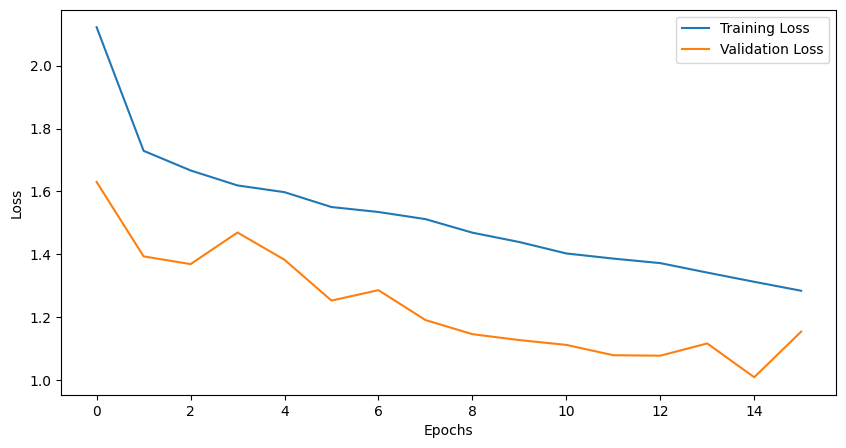

In [12]:
plt.figure(figsize=(10,5))
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [13]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

50
torch.Size([128, 3, 3, 3])


In [18]:
# Wyznaczanie całkowitej jakości klasyfikacji sieci na zbiorze testowym
classes = trainloader.dataset.subset.dataset.classes
net = ResNet(3, len(classes))
net.to('cuda')
net.load_state_dict(torch.load('checkpoints/resnet_epoch_15.pth'))
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images.to('cuda'))
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels.to('cuda')).sum().item()
print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 66 %


In [19]:
# Wyznaczanie jakości klasyfikacji dla poszczególnych klas

# prepare to count predictions for each class
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

# again no gradients needed
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images.to('cuda'))
        _, predictions = torch.max(outputs, 1)
        # collect the correct predictions for each class
        for label, prediction in zip(labels.to('cuda'), predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


# print accuracy for each class
for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

Accuracy for class: dew   is 82.7 %
Accuracy for class: fogsmog is 80.2 %
Accuracy for class: frost is 42.3 %
Accuracy for class: glaze is 27.6 %
Accuracy for class: hail  is 71.0 %
Accuracy for class: lightning is 91.2 %
Accuracy for class: rain  is 30.6 %
Accuracy for class: rainbow is 38.2 %
Accuracy for class: rime  is 83.5 %
Accuracy for class: sandstorm is 79.5 %
Accuracy for class: snow  is 61.5 %


lightning hail  dew   rainbow dew   snow  fogsmog rain  rime  fogsmog rain  rime  hail  hail  dew   fogsmog


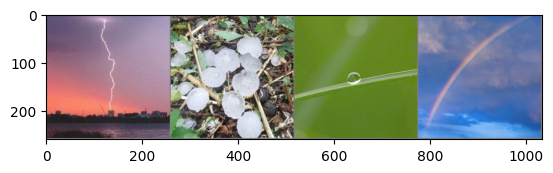

Predicted: lightning, Actual: lightning
Predicted: hail, Actual: hail
Predicted: dew, Actual: dew
Predicted: rainbow, Actual: rainbow


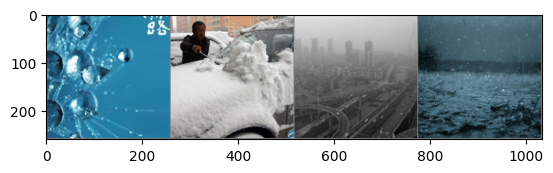

Predicted: lightning, Actual: dew
Predicted: hail, Actual: snow
Predicted: fogsmog, Actual: fogsmog
Predicted: rain, Actual: rain


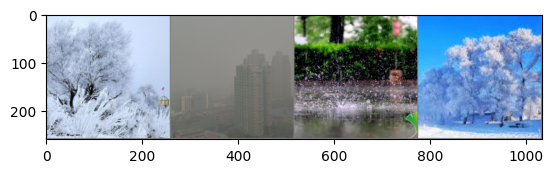

Predicted: rime, Actual: rime
Predicted: fogsmog, Actual: fogsmog
Predicted: frost, Actual: rain
Predicted: rime, Actual: rime


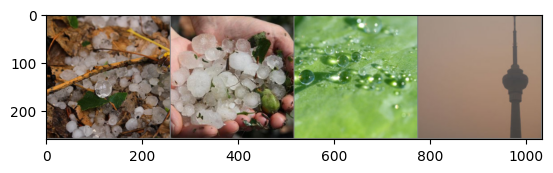

Predicted: hail, Actual: hail
Predicted: hail, Actual: hail
Predicted: dew, Actual: dew
Predicted: sandstorm, Actual: fogsmog


In [20]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()
# get some random training images
dataiter = iter(testloader)
images, labels = next(dataiter)

outputs = net(images.to('cuda'))
_, predicted = torch.max(outputs, 1)

# show images
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

images[0].shape

# display 4 at time
for i in range(4):
    imshow(torchvision.utils.make_grid(images[i*4:4+i*4].cpu()))
    for j in range(4):
        print(f'Predicted: {classes[predicted[i*4+j]]}, Actual: {classes[labels[i*4+j]]}')

In [21]:
print(net)
print(train_transform)
print(test_transform)

ResNet(
  (conv1): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res_layer_1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(128, 256, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResidualBlock(
      (conv1): Conv2d(256, 256, kernel_size=(3, 3), stride

Compose(
    ToTensor()
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    Normalize(mean=(1, 1, 1), std=(1, 1, 1))
)